# Amazon Laptops – Exploratory Data Analysis

This notebook creates **8 visualizations** using the cleaned Amazon laptop dataset.

**Required file:** `cleaned_data.csv` in the same folder as this notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [2]:
df = pd.read_csv("laptops_data_cleaned.csv")

# Create a folder to save visualizations
os.makedirs("visualizations", exist_ok=True)

# Set a clean style for the charts
sns.set_theme(style="whitegrid")

# Display the first few rows
df.head()

,Title,Price,Rating,Brand,Ram,Storage,Color,Processor
0,"HP 15 (i5 14th Gen), Intel Core 5, 16GB RAM (U...","75,990",3.6,Hp,16.0,512.0,Silver,Intel
1,"HP Omnibook 3, Snapdragon X Processor 45 Tops ...","69,990",3.2,Hp,16.0,512.0,Silver,Snapdragon
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,"44,999",4.0,Lenovo,8.0,512.0,Silver,AMD
3,"ASUS Vivobook 16,Smartchoice, 13th Gen, Intel ...","67,990",4.0,Asus,16.0,512.0,Silver,Intel
4,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,"73,990",4.8,Apple,8.0,256.0,Indigo,Unknown


In [3]:
# Check basic information about the cleaned dataset
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())


Rows and columns: (289, 8)

Column names:
['Title', 'Price', 'Rating', 'Brand', 'Ram', 'Storage', 'Color', 'Processor']

Missing values:
Title        0
Price        0
Rating       0
Brand        0
Ram          0
Storage      0
Color        0
Processor    0
dtype: int64


## 1. Number of Laptops by Brand

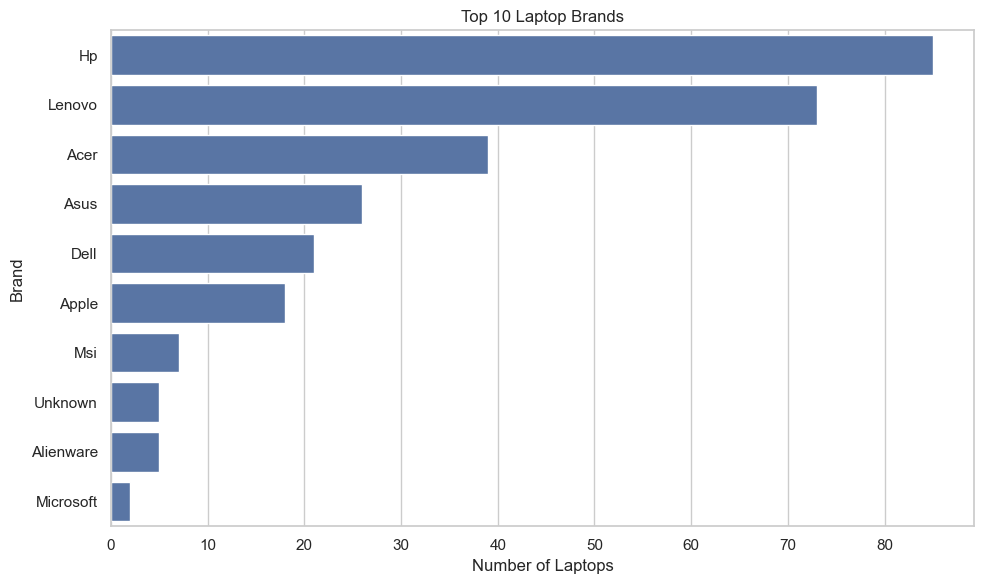

In [4]:
# Count laptops for each brand and select the top 10
brand_counts = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=brand_counts.values, y=brand_counts.index)
plt.title("Top 10 Laptop Brands")
plt.xlabel("Number of Laptops")
plt.ylabel("Brand")
plt.tight_layout()
plt.savefig("visualizations/01_laptops_by_brand.png")
plt.show()

## 2. Laptop Price Distribution


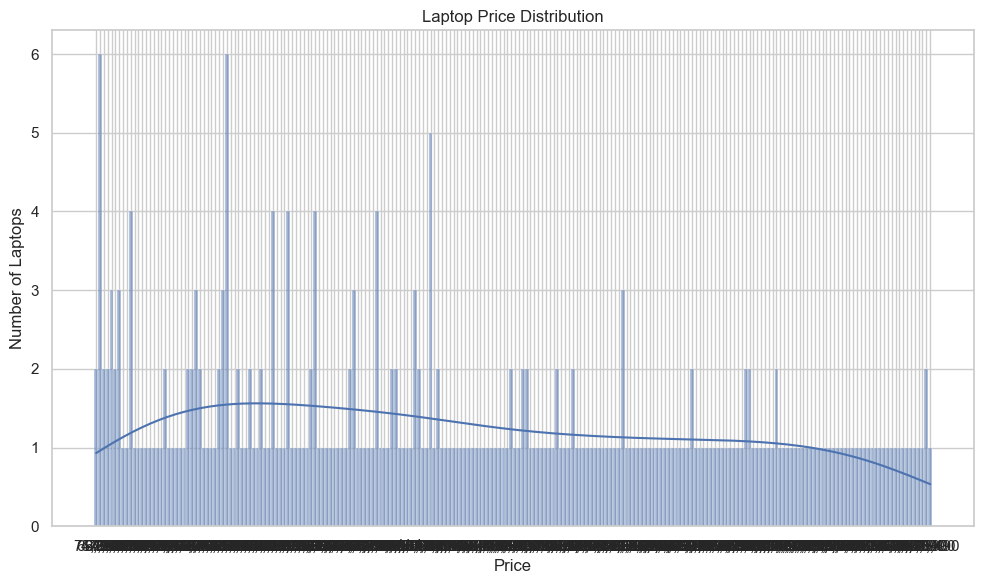

In [6]:
# Show how laptop prices are distributed
plt.figure(figsize=(10, 6))
sns.histplot(df["Price"].dropna(), bins=20, kde=True)
plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Laptops")
plt.tight_layout()
plt.savefig("visualizations/02_price_distribution.png")
plt.show()


## 3. Average Laptop Price by Brand

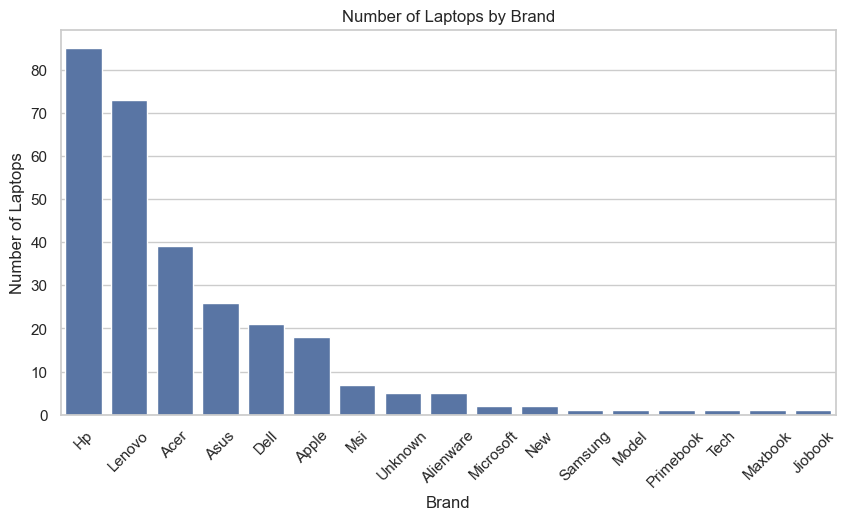

In [10]:
# Calculate average price for each brand and select the top 10
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Brand",
    order=df["Brand"].value_counts().index
)
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Laptops")

plt.xticks(rotation=45)
plt.show()

## 4. RAM Distribution

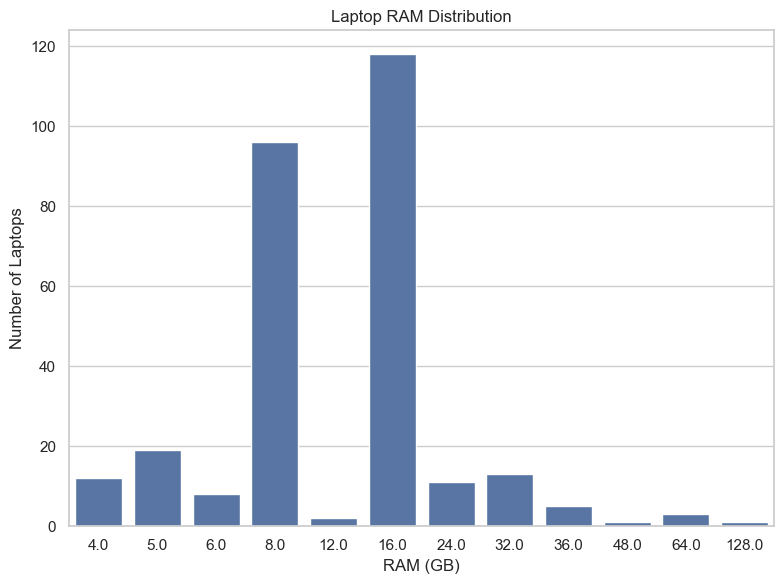

In [12]:
# Count laptops for each RAM value
ram_counts = df["Ram"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=ram_counts.index, y=ram_counts.values)
plt.title("Laptop RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Laptops")
plt.tight_layout()
plt.savefig("visualizations/04_ram_distribution.png")
plt.show()


## 5. Rating Distribution



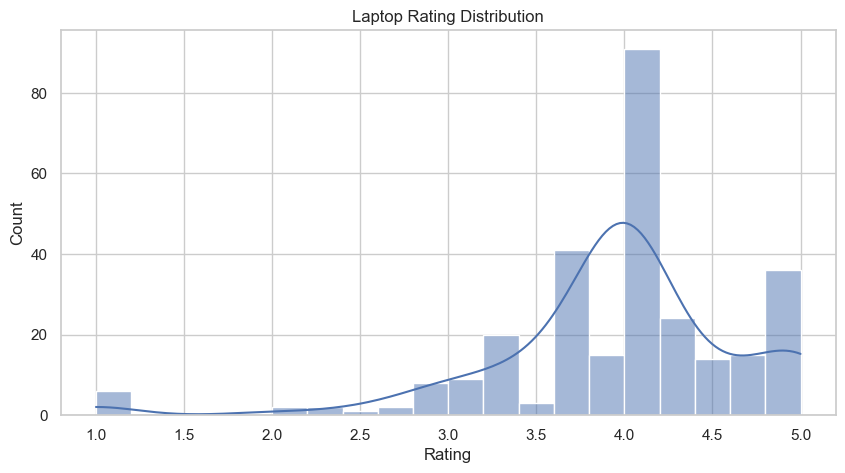

In [15]:
# Show the distribution of laptop ratings
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Rating",
    bins=20,
    kde=True
)
plt.title("Laptop Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# rating boxplots

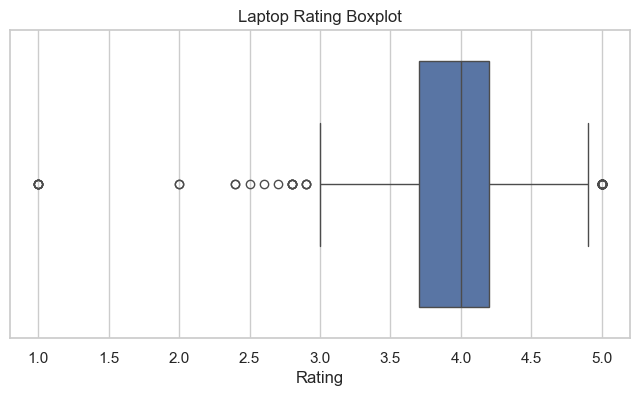

In [17]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Rating"]
)
plt.title("Laptop Rating Boxplot")
plt.xlabel("Rating")
plt.show()

## 6. Price vs RAM



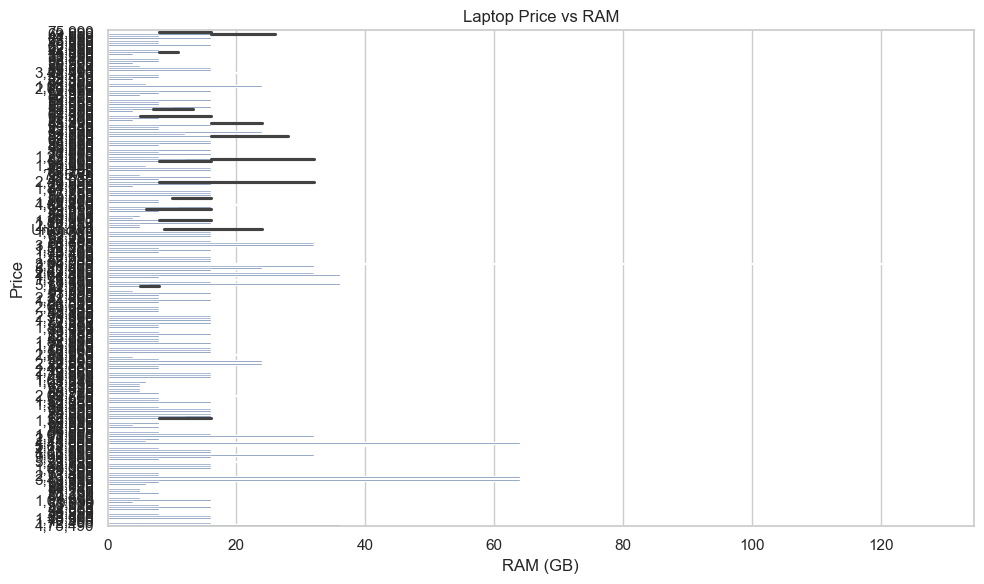

In [20]:
# Compare laptop price with RAM capacity
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Ram", y="Price")
plt.title("Laptop Price vs RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("visualizations/06_price_vs_ram.png")
plt.show()


## 7. Price vs Rating



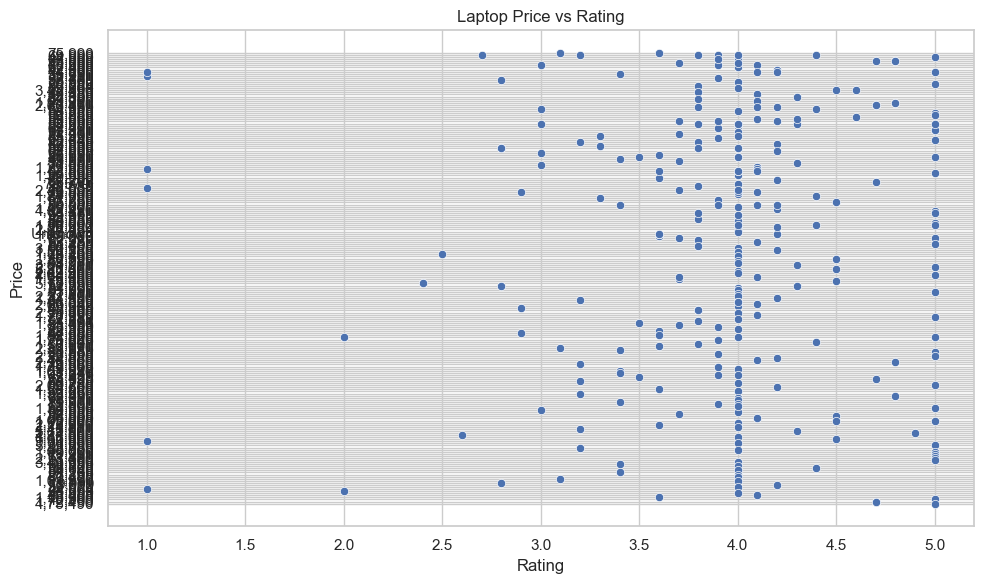

In [22]:
# Compare laptop price with customer rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rating", y="Price")
plt.title("Laptop Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("visualizations/07_price_vs_rating.png")
plt.show()


## 8. Processor Distribution



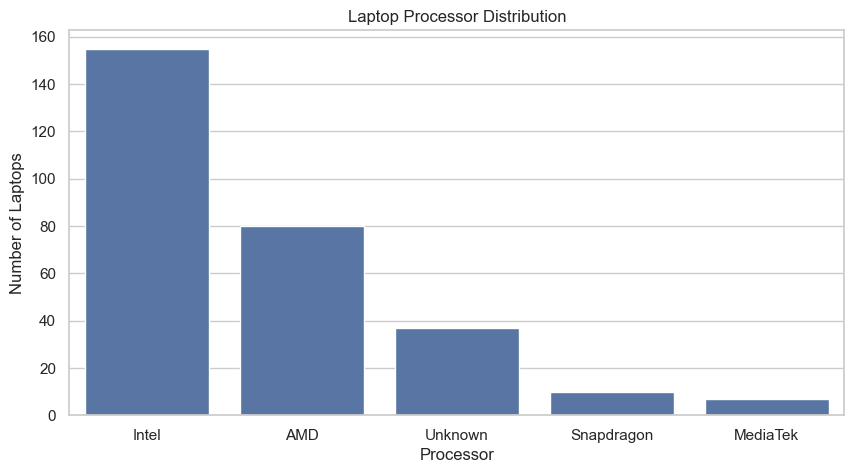

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Processor",
    order=df["Processor"].value_counts().index
)

plt.title("Laptop Processor Distribution")
plt.xlabel("Processor")
plt.ylabel("Number of Laptops")

plt.show()

## color

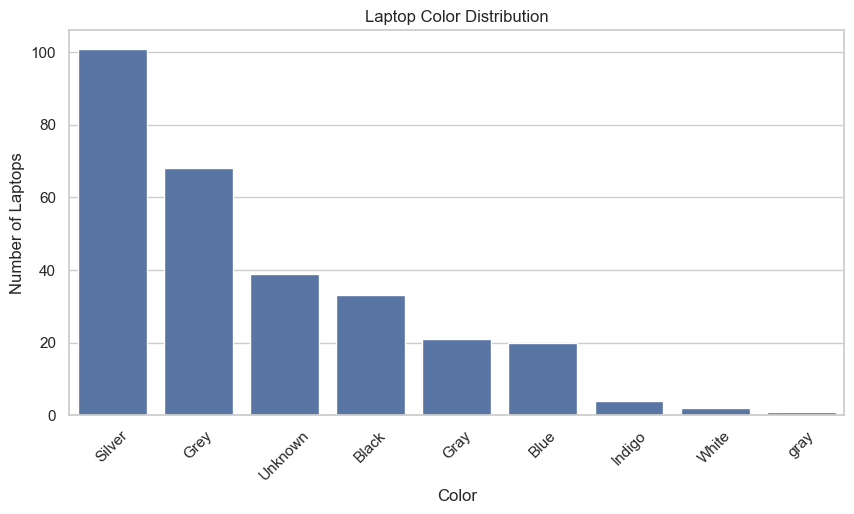

In [26]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Color",
    order=df["Color"].value_counts().index
)

plt.title("Laptop Color Distribution")
plt.xlabel("Color")
plt.ylabel("Number of Laptops")

plt.xticks(rotation=45)

plt.show()

## multi tasks

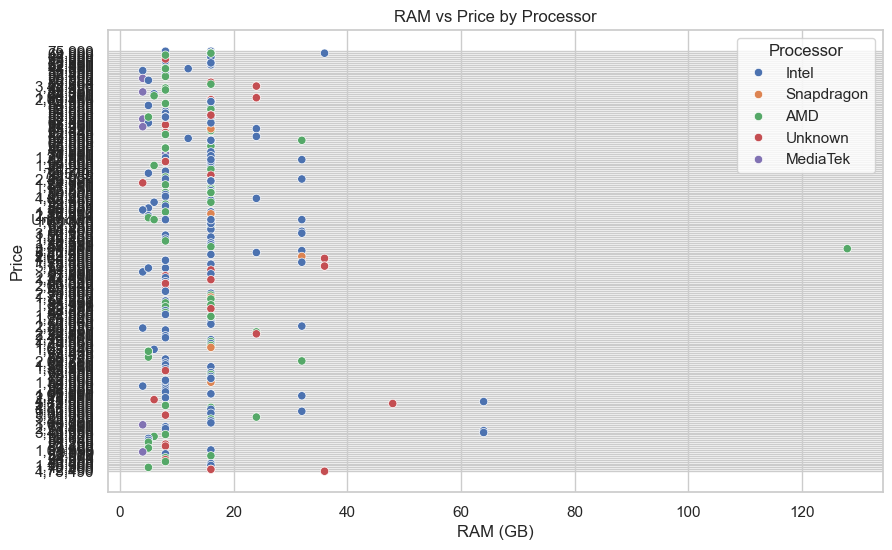

In [27]:
# multi tasks
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Ram",
    y="Price",
    hue="Processor"
)
plt.title("RAM vs Price by Processor")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.show()